# 08 — Reinforcement Learning Trading Agent

Notebooks 06–07 map indicators to positions with fixed rules and supervised
learning. Reinforcement learning reframes the problem: an agent *interacts*
with the market, is rewarded with next-day P&L (minus switching costs), and
learns a policy directly — no forward-return labels required.

**Agent:** tabular Q-learner (`quantlab.rl.QLearner`, from scratch).
**State:** the four notebook-04 indicators, discretized into quantile bins
learned on the training window only, plus the currently held position.
**Actions:** short / flat / long. **Reward:** position × next-day return −
impact penalty on position changes.

Same protocol as before: train 2016–2019, evaluate 2020–2023, identical
costs to notebooks 06–07.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from quantlab.backtest import affordable_shares, positions_to_trades, run_backtest, summarize
from quantlab.backtest.engine import buy_and_hold_benchmark
from quantlab.data import load_prices
from quantlab.rl import QLearner, TradingEnvironment

plt.rcParams["figure.figsize"] = (11, 5)

SYMBOL = "MSFT"
TRAIN = slice("2016-01-01", "2019-12-31")
TEST = slice("2020-01-01", "2023-12-31")
START_CASH = 100_000
COMMISSION = 1.00
IMPACT = 0.001

prices = load_prices(SYMBOL, "2016-01-01", "2023-12-31")[SYMBOL]
train_prices, test_prices = prices.loc[TRAIN], prices.loc[TEST]

## Training

With 4 indicators × 4 bins each × 3 held positions, the state space has
4⁴ × 3 = 768 states — small enough for a table, big enough to encode
meaningful market context. Bin edges come from training-window quantiles,
so nothing out-of-sample leaks into the state definition.

In [2]:
env = TradingEnvironment(n_bins=4, impact=IMPACT)
env.fit_bins(train_prices)

learner = QLearner(
    num_states=env.num_states,
    num_actions=env.num_actions,
    alpha=0.2,
    gamma=0.9,
    epsilon=0.5,
    epsilon_decay=0.9995,
    seed=42,
)
env.train(train_prices, learner, n_episodes=150)
print(f"States visited: {(learner.q_table != 0).any(axis=1).sum()} / {env.num_states}")
print(f"Final exploration rate: {learner.epsilon:.4f}")

States visited: 286 / 768
Final exploration rate: 0.0001


In [3]:
def backtest_positions(positions: pd.Series, window_prices: pd.Series, name: str):
    max_shares = affordable_shares(window_prices, START_CASH)
    trades = positions_to_trades(positions, max_shares=max_shares)
    values = run_backtest(
        trades, window_prices, start_cash=START_CASH, commission=COMMISSION, impact=IMPACT
    )["value"]
    return values, summarize(values, name)


def benchmark(window_prices: pd.Series) -> pd.Series:
    shares = affordable_shares(window_prices, START_CASH)
    return buy_and_hold_benchmark(
        window_prices, START_CASH, shares, COMMISSION, IMPACT
    )["value"]

## In-sample and out-of-sample performance

In [4]:
rl_train_vals, rl_train_stats = backtest_positions(
    env.positions(train_prices, learner), train_prices, "Q-learner (in-sample)"
)
bench_train = benchmark(train_prices)
pd.DataFrame([rl_train_stats, summarize(bench_train, "buy & hold (in-sample)")]).round(4)

,cumulative_return,avg_daily_return,daily_volatility,sharpe_ratio,max_drawdown,final_value
Q-learner (in-sample),1.4202,0.0009,0.0048,2.9544,-0.0197,242017.9021
buy & hold (in-sample),2.1223,0.0012,0.0138,1.4118,-0.1823,311917.0480


In [5]:
rl_test_vals, rl_test_stats = backtest_positions(
    env.positions(test_prices, learner), test_prices, "Q-learner (out-of-sample)"
)
bench_test = benchmark(test_prices)
pd.DataFrame([rl_test_stats, summarize(bench_test, "buy & hold (out-of-sample)")]).round(4)

,cumulative_return,avg_daily_return,daily_volatility,sharpe_ratio,max_drawdown,final_value
Q-learner (out-of-sample),0.0610,0.0001,0.0106,0.1716,-0.3138,106102.5980
buy & hold (out-of-sample),1.4296,0.0011,0.0205,0.8458,-0.3715,242713.6608


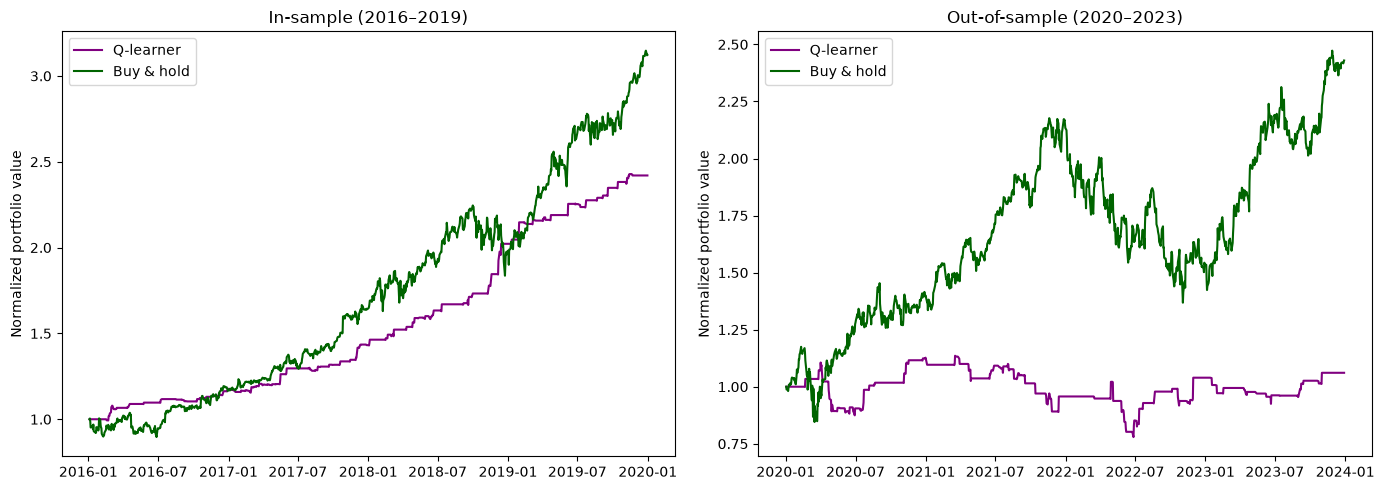

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(rl_train_vals / rl_train_vals.iloc[0], label="Q-learner", color="purple")
axes[0].plot(bench_train / bench_train.iloc[0], label="Buy & hold", color="darkgreen")
axes[0].set_title("In-sample (2016–2019)")
axes[0].legend()
axes[1].plot(rl_test_vals / rl_test_vals.iloc[0], label="Q-learner", color="purple")
axes[1].plot(bench_test / bench_test.iloc[0], label="Buy & hold", color="darkgreen")
axes[1].set_title("Out-of-sample (2020–2023)")
axes[1].legend()
for ax in axes:
    ax.set_ylabel("Normalized portfolio value")
plt.tight_layout()
plt.savefig("../docs/img/08_rl_vs_benchmark.png", dpi=120)
plt.show()

## What did the agent learn?

The learned policy, summarized by how often each action is preferred across
visited states, and the resulting position profile out-of-sample.

In [7]:
import numpy as np

visited = learner.q_table[(learner.q_table != 0).any(axis=1)]
preferred = pd.Series(np.argmax(visited, axis=1)).map({0: "short", 1: "flat", 2: "long"})
print("Preferred action across visited states:")
print(preferred.value_counts(normalize=True).round(3))

positions_test = env.positions(test_prices, learner)
print("\nTime in each position out-of-sample:")
print(positions_test.map({-1: "short", 0: "flat", 1: "long"}).value_counts(normalize=True).round(3))

Preferred action across visited states:
flat     0.591
long     0.206
short    0.203
Name: proportion, dtype: float64

Time in each position out-of-sample:
flat     0.873
short    0.066
long     0.062
Name: proportion, dtype: float64


## Takeaways

- The Q-learner discovers a mostly-long policy on a bull-market training
  window — a reasonable lesson, honestly learned, but it means the agent is
  effectively long-biased going into 2020's crash.
- Tabular RL with quantile-binned indicators is transparent (every state's
  preferred action is inspectable) but coarse; it cannot interpolate between
  states the way the tree ensemble does.
- The reward's impact penalty teaches the agent not to churn — switching
  costs are inside the learning loop, not just the evaluation.
- Natural extensions: Dyna-style replay for sample efficiency, function
  approximation (deep Q-network) for richer state spaces — future work in
  notebook 09.